# 27 — Single Case: IG vs SHAP Attribution — Helpdesk

Enter a case name and prefix length to see side-by-side:
- Integrated Gradients attribution heatmap
- SHAP attribution heatmap

In [7]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(
    model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories)

case_names = list(eval_helper.cases.keys())
print(f'Cases: {len(case_names)}')
print(f'Sample: {case_names[:5]}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Cases: 916
Sample: ['Case 1016', 'Case 102', 'Case 1032', 'Case 1034', 'Case 1039']


In [9]:
# ============================================
# CONFIGURATION — change these
# ============================================
CASE_NAME = "Case 1039"
PREFIX_LENGTH = 1
IG_STEPS = 30
SHAP_SAMPLES = 30
TARGET = CONFIG.concept_name

In [10]:
# Get prefix
case = eval_helper.cases[CASE_NAME]
for pl, prefix, suffix in eval_helper._iterate_case(case):
    if pl == PREFIX_LENGTH:
        break

cat_t = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
num_t = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
process = (cat_t, num_t)

# Compute IG
attr_ig = tool.compute_attribution_map(
    process=process, prefix_length=PREFIX_LENGTH,
    target=TARGET, target_class='auto',
    method='integrated_gradients', n_steps=IG_STEPS)

# Compute SHAP
attr_shap = tool.compute_attribution_map(
    process=process, prefix_length=PREFIX_LENGTH,
    target=TARGET, target_class='auto',
    method='shap', n_samples=SHAP_SAMPLES)

print(f'Case: {CASE_NAME}, Prefix: {PREFIX_LENGTH}')
print(f'IG target:   {attr_ig.target_description}')
print(f'SHAP target: {attr_shap.target_description}')

Case: Case 1039, Prefix: 1
IG target:   Activity = Resolve ticket (class 11) [integrated_gradients]
SHAP target: Activity = Resolve ticket (class 11) [shap]


## Side-by-side heatmaps: IG, SHAP

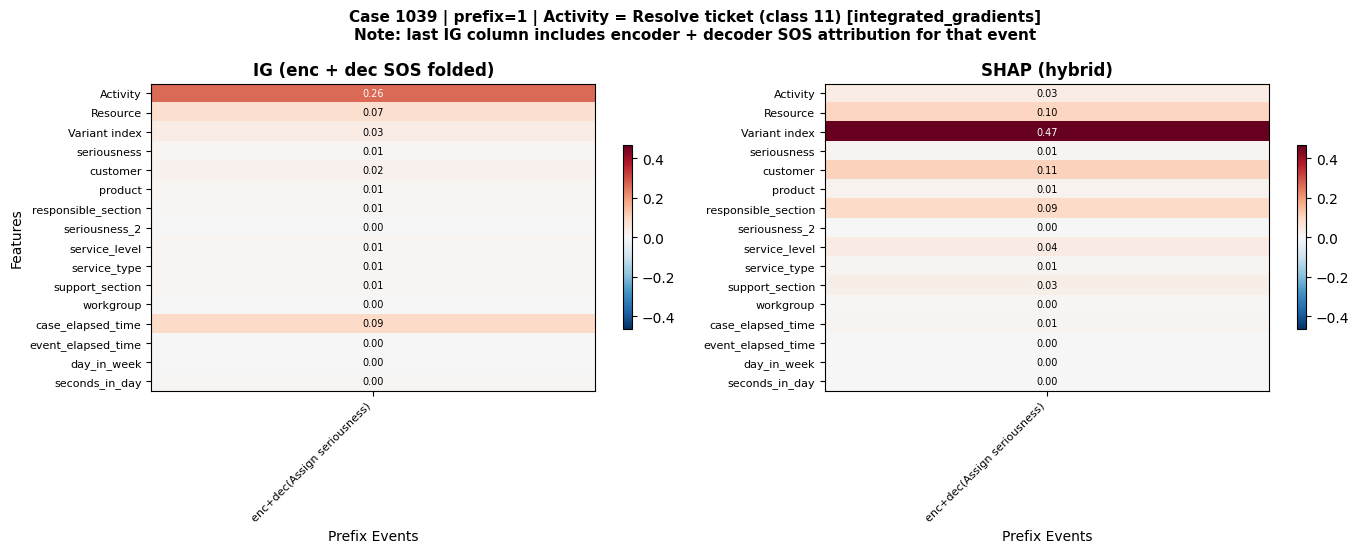

In [11]:
def to_matrix(attr_map, fold_dec_sos=False):
    """Build (features x steps) matrix from AttributionMap.
    If fold_dec_sos=True, add the dec(SOS) column into the last encoder column."""
    n_f = len(attr_map.feature_names)
    n_s = len(attr_map.step_labels)
    mat = np.zeros((n_f, n_s))
    for i, feat in enumerate(attr_map.feature_names):
        if feat in attr_map.attributions:
            vals = attr_map.attributions[feat]
            if hasattr(vals, 'detach'):
                vals = vals.detach().cpu().numpy()
            vals = np.asarray(vals).flatten()
            mat[i, :min(len(vals), n_s)] = vals[:n_s]

    if fold_dec_sos:
        # Find the dec(SOS) column and fold it into the last encoder column
        sos_idx = None
        last_enc_idx = None
        for j, label in enumerate(attr_map.step_labels):
            if label.startswith('dec(SOS'):
                sos_idx = j
            elif label.startswith('enc('):
                last_enc_idx = j
        if sos_idx is not None and last_enc_idx is not None:
            mat[:, last_enc_idx] += mat[:, sos_idx]
            # Remove the SOS column
            keep = [j for j in range(n_s) if j != sos_idx]
            mat = mat[:, keep]
            labels = [attr_map.step_labels[j] for j in keep]
            # Rename last enc label to show it includes SOS
            labels[last_enc_idx] = labels[last_enc_idx].replace('enc(', 'enc+dec(')
            return mat, labels
    return mat, list(attr_map.step_labels)

# IG: fold dec(SOS) into last encoder step
mat_ig, labels_ig = to_matrix(attr_ig, fold_dec_sos=True)
# SHAP: no decoder positions to fold
mat_shap, labels_shap = to_matrix(attr_shap, fold_dec_sos=False)

# Ensure same number of steps (SHAP has only encoder positions)
min_steps = min(mat_ig.shape[1], mat_shap.shape[1])
mat_ig = mat_ig[:, :min_steps]
mat_shap = mat_shap[:, :min_steps]
step_labels = labels_ig[:min_steps]

features = attr_ig.feature_names

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(features) * 0.35)))

vmax_abs = max(np.abs(mat_ig).max(), np.abs(mat_shap).max())
if vmax_abs == 0:
    vmax_abs = 1

for ax, mat, title in zip(axes, [mat_ig, mat_shap],
                           ['IG (enc + dec SOS folded)', 'SHAP (hybrid)']):
    norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0, vmax=vmax_abs)

    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', norm=norm, interpolation='nearest')
    ax.set_xticks(range(len(step_labels)))
    ax.set_xticklabels(step_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prefix Events')
    fig.colorbar(im, ax=ax, shrink=0.6)

    if mat.shape[0] * mat.shape[1] <= 80:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat[i, j]
                color = 'white' if abs(v) > vmax_abs * 0.5 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)

axes[0].set_ylabel('Features')
fig.suptitle(f'{CASE_NAME} | prefix={PREFIX_LENGTH} | {attr_ig.target_description}\n'
             f'Note: last IG column includes encoder + decoder SOS attribution for that event',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature-level summary

In [12]:
ig_totals = np.abs(mat_ig).sum(axis=1)
shap_totals = np.abs(mat_shap).sum(axis=1)
delta_totals = ig_totals - shap_totals

order = np.argsort(np.maximum(ig_totals, shap_totals))[::-1]

print(f'{"Feature":30s} {"IG (enc+dec)":>12s} {"SHAP":>8s} {"Delta":>8s}')
print('-' * 62)
for idx in order:
    print(f'{features[idx]:30s} {ig_totals[idx]:12.4f} {shap_totals[idx]:8.4f} {delta_totals[idx]:+8.4f}')

from scipy.stats import spearmanr
rho, p = spearmanr(ig_totals, shap_totals)
print(f'\nSpearman correlation (feature-level): {rho:.3f} (p={p:.4f})')

Feature                        IG (enc+dec)     SHAP    Delta
--------------------------------------------------------------
Variant index                        0.0331   0.4665  -0.4334
Activity                             0.2627   0.0331  +0.2296
customer                             0.0201   0.1070  -0.0869
Resource                             0.0736   0.0995  -0.0258
responsible_section                  0.0067   0.0909  -0.0842
case_elapsed_time                    0.0885   0.0114  +0.0771
service_level                        0.0076   0.0372  -0.0296
support_section                      0.0075   0.0266  -0.0191
product                              0.0098   0.0149  -0.0051
service_type                         0.0079   0.0128  -0.0049
seriousness                          0.0094   0.0126  -0.0032
workgroup                            0.0019   0.0044  -0.0025
seconds_in_day                       0.0037   0.0020  +0.0017
day_in_week                          0.0034   0.0009  +0.0024
serious